In [21]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [22]:
stocks = [
    "RELIANCE.NS", "TCS.NS", "INFY.NS", "HDFCBANK.NS", "ICICIBANK.NS",
    "SBIN.NS", "ITC.NS", "LT.NS", "KOTAKBANK.NS", "HINDUNILVR.NS",
    "AXISBANK.NS", "ASIANPAINT.NS", "MARUTI.NS", "BAJFINANCE.NS",
    "WIPRO.NS", "ULTRACEMCO.NS", "NTPC.NS", "POWERGRID.NS",
    "TITAN.NS", "ADANIENT.NS"
]

market = "^NSEI"

start = "2013-01-01"
end = "2024-12-31"

data = yf.download(stocks + [market], start=start, end=end)

/tmp/ipykernel_4547/2405894717.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks + [market], start=start, end=end)
[*********************100%***********************]  21 of 21 completed


In [23]:

prices = data['Close']

In [24]:
monthly_prices = prices.resample('ME').last()
returns = monthly_prices.pct_change().dropna()
rf = 0.06 / 12
market_returns = returns[market] - rf
stock_returns = returns.drop(columns=[market]) -rf

In [25]:
summary = stock_returns.describe().T
summary["skew"] = stock_returns.skew()
summary["kurtosis"] = stock_returns.kurtosis()

print("\nSummary Statistics:\n")
print(summary)


Summary Statistics:

               count      mean       std       min       25%       50%  \
Ticker                                                                   
ADANIENT.NS    143.0  0.040892  0.175241 -0.547720 -0.053372  0.033584   
ASIANPAINT.NS  143.0  0.009815  0.074509 -0.175705 -0.040143  0.002106   
AXISBANK.NS    143.0  0.009037  0.094911 -0.461475 -0.045252  0.008567   
BAJFINANCE.NS  143.0  0.030059  0.114118 -0.507694 -0.029268  0.026511   
HDFCBANK.NS    143.0  0.009569  0.061182 -0.273119 -0.033687  0.001362   
HINDUNILVR.NS  143.0  0.009531  0.062578 -0.150371 -0.038585  0.005819   
ICICIBANK.NS   143.0  0.012077  0.084628 -0.353919 -0.032841  0.012351   
INFY.NS        143.0  0.011795  0.073910 -0.231314 -0.032766  0.013365   
ITC.NS         143.0  0.005267  0.060606 -0.177339 -0.029901  0.005098   
KOTAKBANK.NS   143.0  0.008761  0.067378 -0.205142 -0.035213  0.006760   
LT.NS          143.0  0.011101  0.080014 -0.314652 -0.039319  0.007228   
MARUTI.NS      1

In [26]:
momentum = stock_returns.rolling(12).mean()
momentum_rank = momentum.rank(axis=1, pct=True)

winners = stock_returns.where(momentum_rank >= 0.7)
losers = stock_returns.where(momentum_rank <= 0.3)

MOM = winners.mean(axis=1) - losers.mean(axis=1)

In [27]:
volatility = stock_returns.rolling(12).std()
vol_rank = volatility.rank(axis=1, pct=True)

low_vol = stock_returns.where(vol_rank <= 0.3)
high_vol = stock_returns.where(vol_rank >= 0.7)

LOWVOL = low_vol.mean(axis=1) - high_vol.mean(axis=1)

In [28]:
factors = pd.concat([market_returns, MOM, LOWVOL], axis=1)
factors.columns = ["MKT", "MOM", "LOWVOL"]
factors = factors.dropna()

results = {}

for stock in stock_returns.columns:
    df = pd.concat([stock_returns[stock], factors], axis=1).dropna()

    Y = df[stock]
    X = df[["MKT", "MOM", "LOWVOL"]]
    X = sm.add_constant(X)

    model = sm.OLS(Y, X).fit()
    results[stock] = model

# Example output for one stock
print("\nRegression Result (RELIANCE.NS):\n")
print(results["RELIANCE.NS"].summary())



Regression Result (RELIANCE.NS):

                            OLS Regression Results                            
Dep. Variable:            RELIANCE.NS   R-squared:                       0.442
Model:                            OLS   Adj. R-squared:                  0.429
Method:                 Least Squares   F-statistic:                     33.78
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           3.75e-16
Time:                        14:37:54   Log-Likelihood:                 186.52
No. Observations:                 132   AIC:                            -365.0
Df Residuals:                     128   BIC:                            -353.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.

In [29]:
def sharpe_ratio(r):
    return r.mean() / r.std()

performance = pd.DataFrame({
    "Mean Return": [MOM.mean(), LOWVOL.mean(), market_returns.mean()],
    "Std Dev": [MOM.std(), LOWVOL.std(), market_returns.std()],
    "Sharpe Ratio": [
        sharpe_ratio(MOM),
        sharpe_ratio(LOWVOL),
        sharpe_ratio(market_returns)
    ]
}, index=["Momentum", "Low Volatility", "Market"])

print("\nPerformance Comparison:\n")
print(performance)


Performance Comparison:

                Mean Return   Std Dev  Sharpe Ratio
Momentum           0.039948  0.047155      0.847153
Low Volatility    -0.010859  0.059602     -0.182195
Market             0.005660  0.045846      0.123459


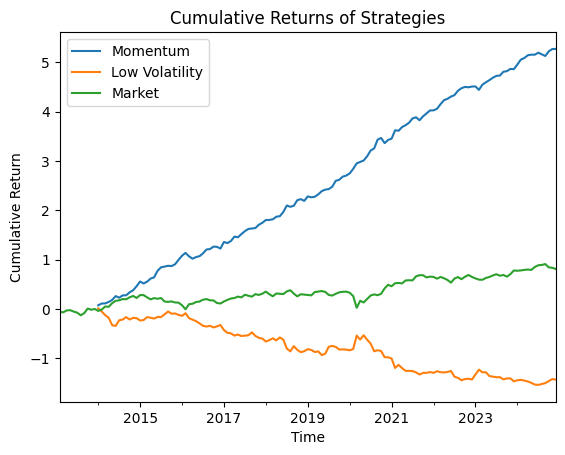

In [30]:
(MOM.cumsum()).plot(label="Momentum")
(LOWVOL.cumsum()).plot(label="Low Volatility")
(market_returns.cumsum()).plot(label="Market")

plt.legend()
plt.title("Cumulative Returns of Strategies")
plt.xlabel("Time")
plt.ylabel("Cumulative Return")
plt.show()

In [31]:
monthly_prices.to_csv("prices_monthly.csv")
returns.to_csv("returns_monthly.csv")
factors.to_csv("factors.csv")
print("Datasets saved successfully!")

Datasets saved successfully!
